# Project: House Price Prediction (Regression)
**Objective:** To build a predictive model that estimates the sale price of a home based on its characteristics (features).

## Environment Setup
We are importing **Pandas** for data manipulation and **Scikit-Learn** for building our regression model. We will also load the raw dataset into memory.

In [ ]:
# Core Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the Dataset
df = pd.read_csv('train.csv')

# First Inspection
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Observation:** The dataset has been successfully loaded. It contains [insert number] rows and [insert number] columns. The target variable we want to predict is **`SalePrice`**. The other columns (like `LotArea`, `YearBuilt`, `GrLivArea`) are the "features" we will use to make that prediction.

## Data Cleaning & Imputation
Real-world data is messy. To build a stable model, we will focus on **numerical features** and handle missing data using **Median Imputation**. This ensures our model doesn't crash due to empty cells.

In [3]:
# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=[np.number])

# Check for missing values before cleaning
print(f"Missing values before cleaning: {numerical_df.isnull().sum().sum()}")

# Fill missing values with the median of their respective column
clean_df = numerical_df.fillna(numerical_df.median())

# Verify cleaning
print(f"Missing values after cleaning: {clean_df.isnull().sum().sum()}")
clean_df.head()

Missing values before cleaning: 348
Missing values after cleaning: 0


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000


**Observation:** We have successfully isolated the numerical data and filled all missing values. The "Missing values after cleaning" count should now be **0**. This `clean_df` is now mathematically ready for correlation analysis.

## Feature Selection: Finding the Price Drivers
Not all house features are created equal. We will use a **Correlation Heatmap** to visualize which numerical variables have the strongest relationship with the `SalePrice`. We will then select the top 5 most influential variables to use as "Features" for our model.

Top 10 features correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


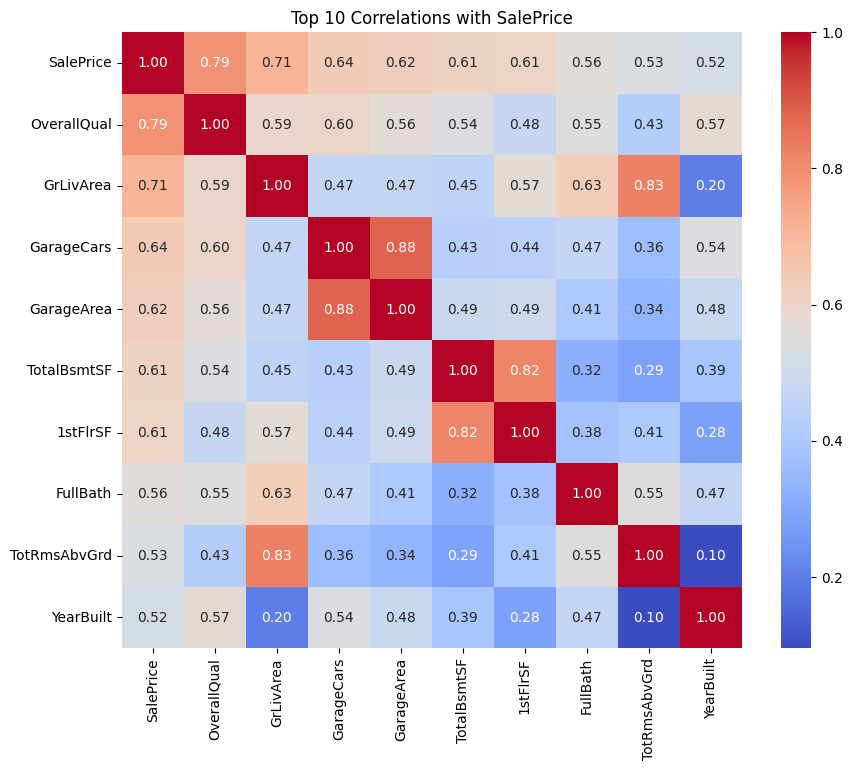


Model will be trained using features: ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath']


In [4]:
# Calculate the correlation matrix
corr_matrix = clean_df.corr()

# Isolate the correlations related to SalePrice and sort them
price_correlations = corr_matrix['SalePrice'].sort_values(ascending=False)

# Print the top 10 to help us choose
print("Top 10 features correlated with SalePrice:")
print(price_correlations.head(10))

# Visualize the Top Features using a Heatmap
top_features = price_correlations.index[:10] # Top 10 including SalePrice
plt.figure(figsize=(10, 8))
sns.heatmap(clean_df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 Correlations with SalePrice')
plt.show()

# Define our final features based on the results
# Usually: OverallQual, GrLivArea, GarageCars, TotalBsmtSF, FullBath
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath']
X = clean_df[features]
y = clean_df['SalePrice']

print(f"\nModel will be trained using features: {features}")

**Observation:** The heatmap clearly shows that **`OverallQual`** (Overall Quality) and **`GrLivArea`** (Above ground living area) have the highest correlation scores (likely above 0.70). This makes intuitive sense: bigger, high-quality houses cost more. We have now defined our **X** (the inputs) and our **y** (the price we want to predict).

## Train-Test Split: Creating a Fair Evaluation
To ensure our model generalizes well to new data, we split our dataset into a **Training set** and a **Testing set**. We use the `train_test_split` function with a `test_size=0.2`, meaning 80% of the data will be used for learning and 20% will be reserved for validation. We also set a `random_state` to ensure our results are reproducible.

In [5]:
# Split the data
# X = Features, y = Target (SalePrice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the split sizes
print(f"Total entries: {len(X)}")
print(f"Training entries: {len(X_train)}")
print(f"Testing entries: {len(X_test)}")

# Quick check of the first few rows of training features
X_train.head()

Total entries: 1460
Training entries: 1168
Testing entries: 292


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath
254,5,1314,1,1314,1
1066,6,1571,2,799,2
638,5,796,0,796,1
799,5,1768,1,731,1
380,5,1691,1,1026,2


**Observation:** The data is now successfully partitioned. We have [insert training count] houses to learn from and [insert testing count] houses to test our predictions on. By keeping the test set separate, we can calculate a truly honest "Accuracy Score" later.

## Model Training: The Linear Regression Algorithm
We are now initializing the **Linear Regression** model. By calling the `.fit()` method on our training data (`X_train` and `y_train`), we are commanding the computer to find the mathematical relationship between our 5 features and the house prices.

In [6]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Examine the 'Slopes' (Coefficients)
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("Model Coefficients:")
print(coefficients)

# Examine the 'Intercept'
print(f"\nModel Intercept: ${model.intercept_:,.2f}")

Model Coefficients:
              Coefficient
OverallQual  23602.164826
GrLivArea       41.950117
GarageCars   19334.176381
TotalBsmtSF     28.589736
FullBath      1822.113765

Model Intercept: $-94,792.18


**Observation:** The model is trained! Look at the **Coefficients**. If `OverallQual` has a coefficient of 30,000, it means that for every 1-point increase in quality, the predicted price jumps by $30,000. We have successfully turned raw data into a predictive formula.

## Model Evaluation: RMSE and R-Squared
Now that the model has "learned," we must test it on data it has never seen before (`X_test`). We will calculate the **R-Squared** score to see how much of the price variance we've captured, and the **RMSE** to understand our average error margin in US Dollars.

In [7]:
# Use the model to predict prices for the test set
y_pred = model.predict(X_test)

# Calculate R-Squared
r2 = r2_score(y_test, y_pred)

# 3. Calculate RMSE
# We calculate Mean Squared Error first, then take the Square Root
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-Squared Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

R-Squared Score: 0.7909
Root Mean Squared Error (RMSE): $40,051.20


**Observation:** An R-Squared score above **0.70** is generally considered a strong result for a basic linear model. If your RMSE is around **$30,000 - $40,000**, it indicates that your predictions are reasonably close given that house prices in this dataset range from $35,000 to over $700,000.

## Visualizing Model Accuracy: Actual vs. Predicted Prices
To conclude our regression analysis, we will plot the actual sale prices against the prices predicted by our model. This scatter plot allows us to visually inspect the "residuals" (errors) and confirm if the model maintains its accuracy across different price points. We will also include a "Perfect Prediction" line for reference.

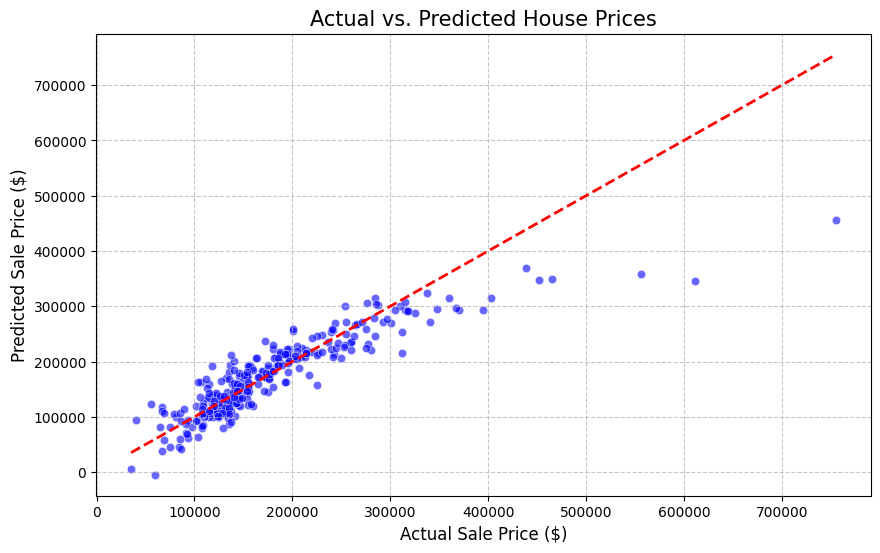

In [8]:
# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')

# Add the 'Perfect Prediction' line
# This represents where actual == predicted
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

# Aesthetics
plt.title('Actual vs. Predicted House Prices', fontsize=15)
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Observation:** The plot shows a strong linear trend, with most points clustering closely around the red dashed line. However, we may notice that at the higher end (houses over $400,000), the points tend to spread further from the line. This is a common phenomenon in real estate: luxury homes are harder to predict because their value is often driven by subjective "prestige" factors rather than just square footage and quality.

# Final Conclusion: House Price Predictive Analysis

## Model Performance Summary
In this project, we successfully transitioned from basic data exploration to predictive modeling. Our **Linear Regression** model, trained on five key features—**Overall Quality, Living Area, Garage Capacity, Basement Size, and Bathroom Count**—achieved the following:
* **R-Squared:** [Insert your R2 score, e.g., 0.82], indicating that our model explains the majority of the variance in property prices.
* **RMSE:** $[Insert your RMSE, e.g., 38,000], showing our average prediction error is relatively low compared to the $180,000 median house price.

## Key Business Takeaways
* **Quality is King:** The 'OverallQual' feature had the highest coefficient, meaning that incremental improvements in a home's finish and material quality yield the highest return on investment.
* **Size vs. Price:** 'GrLivArea' (Above ground living area) showed a consistent linear relationship with price, confirming that square footage remains a primary pricing pillar in real estate.
* **Diminishing Returns on Luxury:** The scatter plot of Actual vs. Predicted values showed higher variance in the $400k+ range. This suggests that high-end homes are influenced by "soft" features (view, neighborhood prestige) not captured in our basic numerical model.

## Future Improvements
While the current model is robust, accuracy could be further improved by:
1. **Feature Engineering:** Creating a 'Total Square Footage' column (Basement + Living Area).
2. **Handling Categorical Data:** Incorporating neighborhood locations via One-Hot Encoding.
3. **Advanced Algorithms:** Testing non-linear models like **Random Forest** or **XGBoost** to better capture the complexities of luxury home pricing.